In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [2]:
orders = pd.read_csv("Data/Raw/olist_orders_dataset.csv")
orders_items = pd.read_csv("Data/Raw/olist_order_items_dataset.csv")
payments = pd.read_csv("Data/Raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("Data/Raw/olist_order_reviews_dataset.csv")
customers = pd.read_csv("Data/Raw/olist_customers_dataset.csv")
products = pd.read_csv("Data/Raw/olist_products_dataset.csv")
sellers = pd.read_csv("Data/Raw/olist_sellers_dataset.csv")
geo = pd.read_csv("Data/Raw/olist_geolocation_dataset.csv")
category_traslation = pd.read_csv("Data/Raw/product_category_name_translation.csv")

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
orders.info()
orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [3]:
date_columns = ['order_purchase_timestamp',
                'order_approved_at',
                'order_delivered_carrier_date',
                'order_delivered_customer_date',
                'order_estimated_delivery_date'
                ]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])   #Convertir fechas, clave para analisis temporal 

delivered_orders =orders[orders['order_status'] == 'delivered'].copy()

In [4]:
#Variables logisticas
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['shipping_days'] = (orders['order_delivered_carrier_date'] - orders['order_purchase_timestamp']).dt.days
orders['delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

delivered_orders['delivery_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.days
delivered_orders['delay_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']).dt.days


In [5]:
orders['on_time'] = orders['delay_days'].apply(lambda x:1 if x <=0 else 0)
delivered_orders['on_time'] = delivered_orders['delay_days'].apply(lambda x: 1 if x<=0 else 0)

<h6> 
Cual es el tiempo promedio de entrega ? <br>

In [10]:
print(f"Days : {round(orders['delivery_days'].mean(),3)}")
print(f"Days : {round(delivered_orders['delivery_days'].mean(),3)}")

Days : 12.094
Days : 12.094


<h6> 
Que porcentaje de pedidos llegan a tiempo ?

In [11]:
print(f"{orders['on_time'].mean()}")
print(f"{delivered_orders['on_time'].mean()}")


0.9044659647429129
0.9321917950206264


In [12]:
delivered_orders['delay_days'].describe()

count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64

<Axes: >

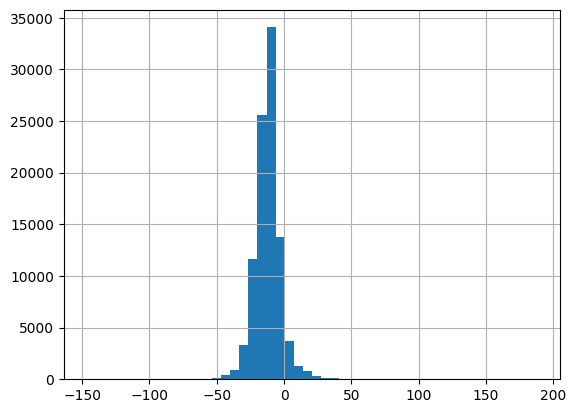

In [13]:
delivered_orders['delay_days'].hist(bins=50)

<h6> Cuantos pedidos hay por estado ?

In [14]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

<h6> Evolución de pedidos por mes 

In [6]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders.groupby('month')['order_id'].count()

month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

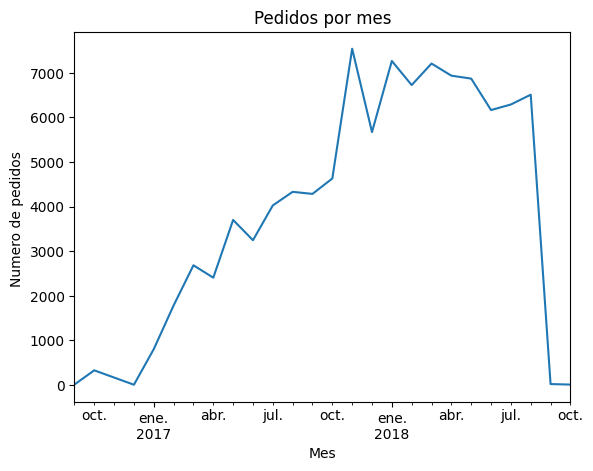

In [7]:
monthly_orders = orders.groupby('month')['order_id'].count()
monthly_orders.plot()
plt.title('Pedidos por mes')
plt.xlabel('Mes')
plt.ylabel('Numero de pedidos ')
plt.show()

<h6>
Mes con mas pedidos 

In [17]:
print(monthly_orders.idxmax(), monthly_orders.max())

2017-11 7544


<h6>
Pedidos totales

In [18]:
orders['order_id'].count()

99441

In [19]:
#Porcenrtaje de pedidos retrasados 

late_rate = 1- delivered_orders['on_time'].mean()
print(f"% pedidos retrasados: {round(late_rate,4)}")

% pedidos retrasados: 0.0678


In [20]:
#Cuantos pedidos delivered hay 
delivered_orders['customer_id'].count()

96478

In [21]:
## Construir tabla de ventas 

orders_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
##|order_id| total_price | total_freight | total_items

order_revenue = orders_items.groupby('order_id').agg(
    total_price = ('price', 'sum'),
    total_freight = ('freight_value', 'sum'),
    total_items = ('order_item_id', 'count')
).reset_index()

# sales contiene: información de pedidos, tiempos de entrega, ingresos, número de productos
sales = delivered_orders.merge(
    order_revenue,
    on='order_id',
    how='left'
)

<h6> Metricas de negocio

In [9]:
# ingreso total
sales['total_revenue'] = sales['total_price'] + sales['total_freight']

#Ticket promedio
print(f"Ticket promedio: {sales['total_revenue'].mean()}")

#ingreso total del dataset
print(f"Ingresos totales: {sales['total_revenue'].sum()}")

#Número promedio de productos pedido
print(f"Promedio de productos por pediod: {sales['total_items'].mean()}")

#Tendencia de ventas por mes
sales['month'] = sales['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = sales.groupby('month')['total_revenue'].sum()


Ticket promedio: 159.82683876116837
Ingresos totales: 15419773.750000002
Promedio de productos por pediod: 1.1421982213561641


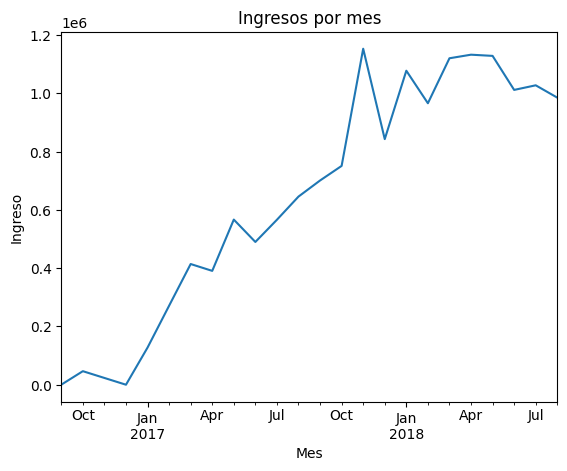

In [24]:
monthly_revenue.plot()

plt.title('Ingresos por mes')
plt.xlabel('Mes')
plt.ylabel('Ingreso')
plt.show()

In [25]:
print(f"Mes con mayor ingreso: {str(monthly_revenue.idxmax()).split('-')[1], monthly_revenue.max()}")

Mes con mayor ingreso: ('11', 1153364.2)


## <h6> conclusiones 
<h6>

* El ticket promedio alto indica que los pedidos suelen tener 1 producto, no muchos producto baratos
* pico en viembre (black friday)


In [26]:

#Unir items con produtos 
items_products = orders_items.merge(
    products,
    on= 'product_id',
    how= 'left'
)

In [27]:
items_products = items_products.merge(
    category_traslation,
    on= 'product_category_name',
    how='left'
    )

In [28]:
#ventas por categoria
category_sales = items_products.groupby(
    'product_category_name_english'
).agg(
    revenue = ('price', 'sum'),
    items_sold = ('order_item_id', 'count')
).sort_values('revenue', ascending=False)
category_sales.head(10)

,revenue,items_sold
product_category_name_english,,
health_beauty,1258681.34,9670
watches_gifts,1205005.68,5991
bed_bath_table,1036988.68,11115
sports_leisure,988048.97,8641
computers_accessories,911954.32,7827
furniture_decor,729762.49,8334
cool_stuff,635290.85,3796
housewares,632248.66,6964
auto,592720.11,4235


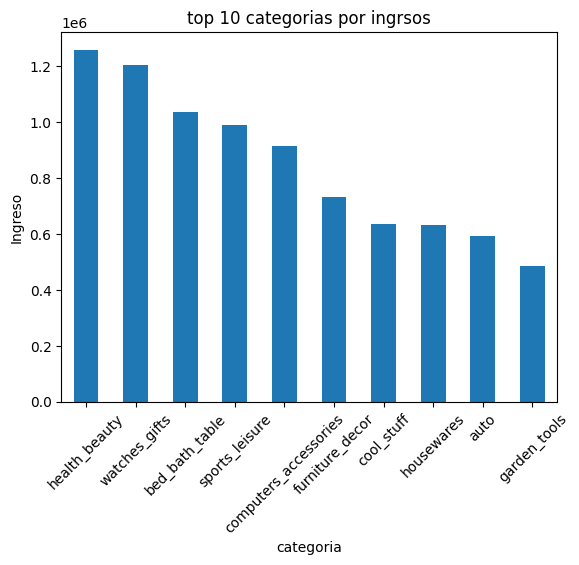

In [29]:
top10 = category_sales.head(10)
top10['revenue'].plot(kind='bar')
plt.title('top 10 categorias por ingrsos')  
plt.xlabel('categoria')
plt.ylabel('Ingreso')
plt.xticks(rotation=45)
plt.show() 

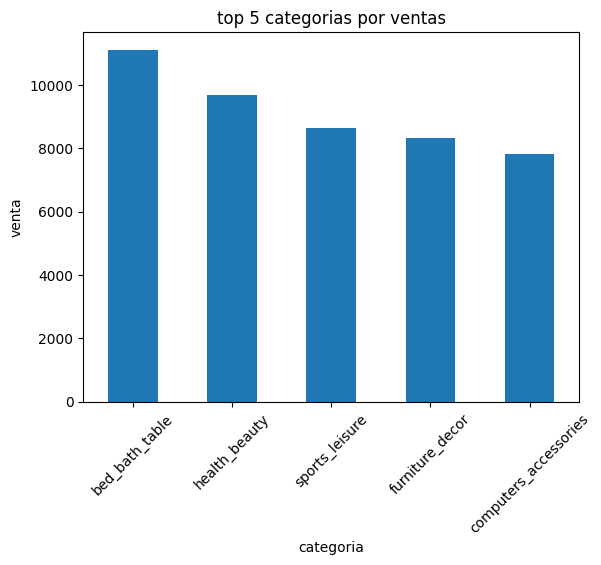

In [30]:

top5_sold = category_sales['items_sold'].sort_values(ascending=False).head(5)
top5_sold.plot(kind='bar')
plt.title('top 5 categorias por ventas')  
plt.xlabel('categoria')
plt.ylabel('venta')
plt.xticks(rotation=45)
plt.show() 

<h6> 
 
* Health&Beauty es la categoria que mas genera dinero
* bed bath table vende mucho volumen pero no necesariamente con los precios mas altos 
* Algunas categorías generan volumen otras generan ingreso 

<h6> Conectar logistica -> Satisfacción del cliente <br>
¿ Los retrasos afectan las reviews ?

In [ ]:
reviews_orders = reviews.merge(
    delivered_orders,
    on= 'order_id',
    how= 'inner'                
    )

In [32]:
#promedio de reviews
reviews_orders['review_score'].mean()

4.155716524320005

In [33]:
#Comprar pedidos a tiempo vs retrasados
#on_time =1 -> entrega a tiempo, 0 retrasado
reviews_orders.groupby('on_time')['review_score'].mean()

on_time
0    2.273804
1    4.289980
Name: review_score, dtype: float64

In [34]:
#Distribución de reviews
reviews_orders['review_score'].value_counts().sort_index()

review_score
1     9406
2     2941
3     7961
4    18987
5    57066
Name: count, dtype: int64

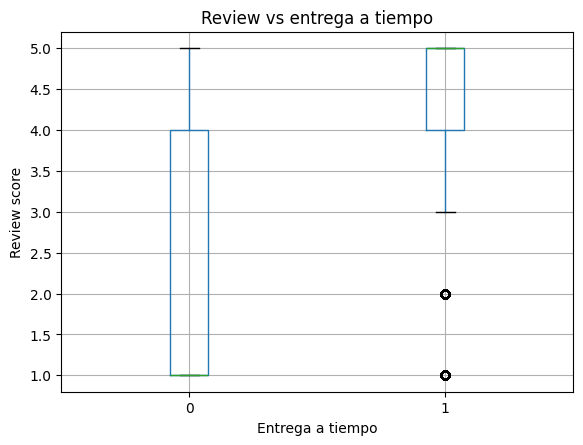

In [35]:
reviews_orders.boxplot(
    column='review_score',
    by='on_time'
)
plt.title('Review vs entrega a tiempo')
plt.suptitle('')
plt.xlabel('Entrega a tiempo')
plt.ylabel('Review score')
plt.show()

<h6> Los retrasos reducen significativamente la satisfacción del cliente

* Los pedidos retrasados tienen una caída muyu fuerete en tsatisfacción. diferecnia aproximada 2 puntos de review
* La logistica impacta directamente la satisfacción
* Reducir retrasos tenderia un impacto grande en experiencia del cliente

Los pedidos entregados a tiempo tiene un calificación promedio de 4.29, mientras que los pedidos retrasados presentan una clasificación promedio de 2.77. Esto evidencia que los retrasos en la entrega afectan significativamente la satisfación del cliente

In [ ]:
# Analisis geografico de ventas
#¿En que región se vende mas 

sales_customers = sales.merge(
    customers,
    on='customer_id',
    how='left'
)
sales_customers.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,on_time,total_price,total_freight,total_items,total_revenue,month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,1,29.99,8.72,1,38.71,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,1,118.70,22.76,1,141.46,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,1,159.90,19.22,1,179.12,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,1,45.00,27.20,1,72.20,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,1,19.90,8.72,1,28.62,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [37]:
#Ventas por estado
state_sales = sales_customers.groupby(
    'customer_state'
).agg(
    revenue=('total_revenue', 'sum'),
    orders=('order_id', 'count')
).sort_values('revenue', ascending=False)

state_sales.head(10)

,revenue,orders
customer_state,,
SP,5769703.15,40501
RJ,2055401.57,12350
MG,1818891.67,11354
RS,861472.79,5345
PR,781708.80,4923
SC,595127.78,3546
BA,591137.81,3256
DF,346123.35,2080
GO,334212.35,1957


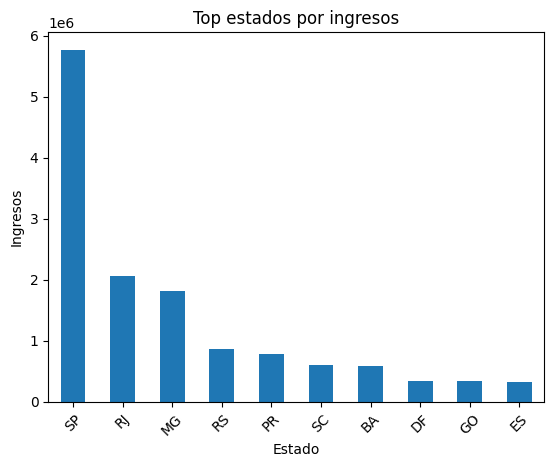

In [38]:
top_sales = state_sales.head(10)
top_sales['revenue'].plot(kind='bar')
plt.title('Top estados por ingresos')
plt.xlabel('Estado')
plt.ylabel('Ingresos')

plt.xticks(rotation=45)

plt.show()

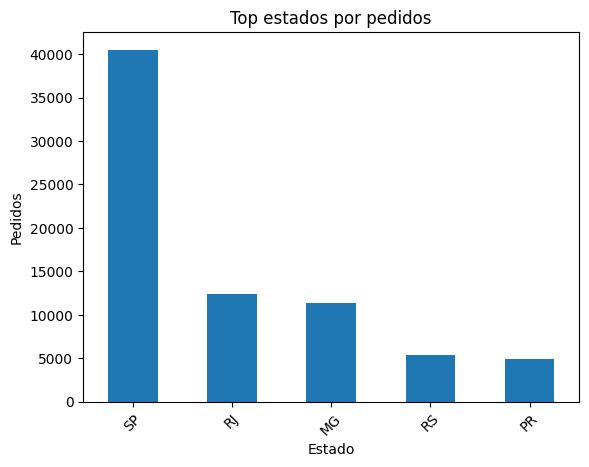

In [39]:
top5_orders = state_sales['orders'].sort_values(ascending=False).head(5)
top5_orders.plot(kind='bar')
plt.title('Top estados por pedidos')
plt.xlabel('Estado')
plt.ylabel('Pedidos')

plt.xticks(rotation=45)

plt.show()

<h6> Las ventas se concentran principalmente en los estados del sureste de Brasil, especialemte en sao paulo, que  lidera tanto en ingresos como en pedidos. Refleja la densidad poblacional y el desarrollo de la región

<h5> RFM Analysis <br>
<h6>

* Recency
* Frequency
* Monetary 

In [ ]:
snapshot_date = sales['order_purchase_timestamp'].max()    # Calcular fecha de referencia (ultima fecha de dataset)

#Tabla RFM
rfm = sales.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'total_revenue': 'sum'
})
rfm.columns = ['recency', 'frequency', 'monetary']
rfm.describe()

,recency,frequency,monetary
count,96478.000000,96478.0,96478.000000
mean,239.121364,1.0,159.826839
std,152.836972,0.0,218.794219
min,0.000000,1.0,9.590000
25%,115.000000,1.0,61.850000
50%,220.000000,1.0,105.280000
75%,349.000000,1.0,176.260000
max,713.000000,1.0,13664.080000


In [41]:
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])      # Scores RFM (quintiles)
rfm['f_Score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4 ,5])

In [42]:
rfm['rfm_score']=(
    rfm['recency'].astype(str)+
    rfm['frequency'].astype(str)+
    rfm['monetary'].astype(str)
)

In [43]:
rfm.sort_values('monetary', ascending=False).head(10)

,recency,frequency,monetary,r_score,f_Score,m_score,rfm_score
customer_id,,,,,,,
1617b1357756262bfa56ab541c47bc16,333,1,13664.08,2,1,5,333113664.08
ec5b2ba62e574342386871631fafd3fc,45,1,7274.88,5,5,5,4517274.88
c6e2731c5b391845f6800c97401a43a9,562,1,6929.31,1,4,5,56216929.31
f48d464a0baaea338cb25f816991ab1f,34,1,6922.21,5,5,5,3416922.21
3fd6777bbce08a352fddd04e4a7cc8f6,461,1,6726.66,1,2,5,46116726.66
05455dfa7cd02f13d132aa7a6a9729c6,278,1,6081.54,2,1,5,27816081.54
df55c14d1476a9a3467f131269c2477f,514,1,4950.34,1,5,5,51414950.34
24bbf5fd2f2e1b359ee7de94defc4a15,497,1,4764.34,1,1,5,49714764.34
3d979689f636322c62418b6346b1c6d2,68,1,4681.78,5,2,5,6814681.78


In [44]:
print(f"Recency promedio: {rfm['recency'].mean()}")
print(f"Frequency promedio: {rfm['frequency'].mean()}")
print(f"Monetary promedio: {rfm['monetary'].mean()}")

Recency promedio: 239.12136445614544
Frequency promedio: 1.0
Monetary promedio: 159.82683876116835


<h6> Frequency promedio = 1 indica  que la mayoria de los clientes compro una sola vez. <br>
Retención baja 

<h5> Cohort Analysis (retención) <br>
<h6> Que porcentaje de clientes vuelve a comprar despues de la primera compra ?

In [ ]:
sales_customers = sales.merge(
    customers,
    on="customer_id",
    how="left"
)

In [46]:
sales_customers['order_month'] = sales_customers['order_purchase_timestamp'].dt.to_period('M')

first_purchase = sales_customers.groupby('customer_unique_id')['order_month'].min()  ## Mes de priemra compra del cliente
sales_customers['cohort_month'] = sales_customers['customer_unique_id'].map(first_purchase)

In [47]:
##Indice de cohorte
sales_customers['cohort_index'] = (
    (sales_customers['order_month']-sales_customers['cohort_month'])
    ).apply(lambda x:x.n)

In [48]:
sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,on_time,total_price,total_freight,total_items,total_revenue,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,1,29.99,8.72,1,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,1,118.70,22.76,1,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,1,159.90,19.22,1,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,1,45.00,27.20,1,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,1,19.90,8.72,1,28.62,2018-02


In [49]:
#Tabla de cortes
cohort_data = sales_customers.groupby(
    ['cohort_month', 'cohort_index']
).agg(
    customer=('customer_unique_id', 'nunique')
).reset_index()

In [50]:
#pivot table
cohort_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer'
)

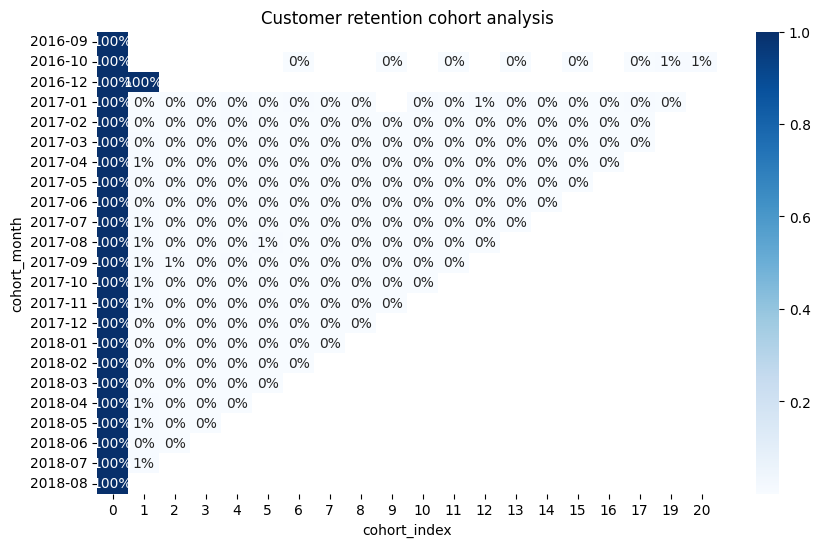

In [51]:
cohort_retention = cohort_table.divide(
    cohort_table.iloc[:,0],
    axis=0
)
plt.figure(figsize=(10,6))

sns.heatmap(
    cohort_retention,
    annot=True,
    fmt='.0%',
    cmap='Blues'
)
plt.title('Customer retention cohort analysis')
plt.show()

<h6> El dataset tiene muy poca retención <br>
El análisis de cohortes muestra que menos del 1% de los cleitnes realiza una segunda compra en el mes siguiente

<h5> Modelo de predicción de retrasos <br>

<h6>
Shipping_days, total_items. total_price, freight_value, estado del cliente, categoría del producto

In [52]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,shipping_days,dealy_days,on_time,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2.0,-8.0,1,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,-6.0,1,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0.0,-18.0,1,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,3.0,-13.0,1,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,0.0,-10.0,1,2018-02


In [53]:
sales_customers.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_days', 'delay_days', 'on_time', 'total_price',
       'total_freight', 'total_items', 'total_revenue', 'month',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_month', 'cohort_month', 'cohort_index'],
      dtype='object')

In [54]:
sales_customers['shipping_days']= (
    sales_customers['order_delivered_carrier_date']-sales_customers['order_purchase_timestamp']
).dt.days

In [55]:
sales_customers['shipping_days'].isna().sum()

2

In [56]:
sales_customers=sales_customers.dropna(subset=['shipping_days'])

In [57]:
ml_data = sales_customers.copy()

In [58]:
ml_data['late'] = ml_data['delay_days'].apply(
    lambda x: 1 if x > 0 else 0
)

In [59]:
features = ml_data[
[
    'shipping_days',
    'total_items',
    'total_price'
]
]
target = ml_data['late']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)
model =RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [61]:
pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96     18032
           1       0.24      0.07      0.11      1264

    accuracy                           0.92     19296
   macro avg       0.59      0.53      0.53     19296
weighted avg       0.89      0.92      0.90     19296



<h5> Análisis de rentabilidad por categoría <br>
<h6>
freight_values como proxy de costo logistico

In [62]:
#Margen
items_products['profit_proxy'] = (
    items_products['price'] - items_products['freight_value']
)

In [63]:
#Rentabilidad por categoria
category_profit = items_products.groupby(
    'product_category_name_english'
).agg(
    revenue=('price', 'sum'),
    freight_cost = ('freight_value', 'sum'),
    profit= ('profit_proxy', 'sum'),
    items=('order_item_id', 'count')
).sort_values('profit', ascending=False)

In [64]:
#Categorias más rentables
category_profit.head(10)

,revenue,freight_cost,profit,items
product_category_name_english,,,,
watches_gifts,1205005.68,100535.93,1104469.75,5991
health_beauty,1258681.34,182566.73,1076114.61,9670
bed_bath_table,1036988.68,204693.04,832295.64,11115
sports_leisure,988048.97,168607.51,819441.46,8641
computers_accessories,911954.32,147318.08,764636.24,7827
furniture_decor,729762.49,172749.30,557013.19,8334
cool_stuff,635290.85,84039.10,551251.75,3796
auto,592720.11,92664.21,500055.90,4235
housewares,632248.66,146149.11,486099.55,6964


In [65]:
#margen promedio
category_profit['avg_margin'] = (
    category_profit['profit'] / category_profit['revenue']
)

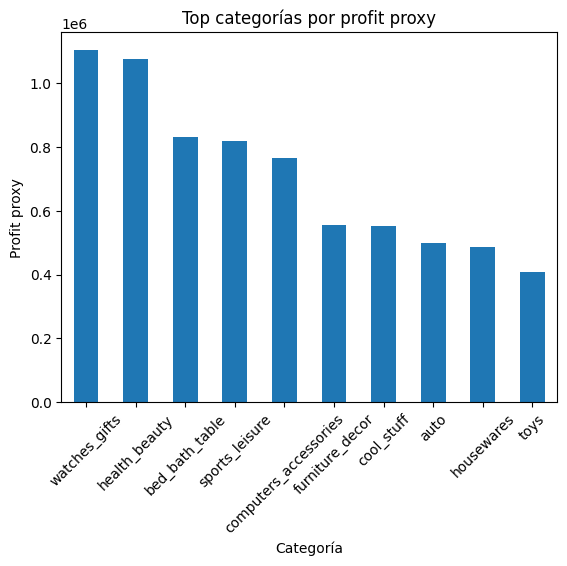

In [66]:
top_profit = category_profit.head(10)
top_profit['profit'].plot(kind='bar')

plt.title('Top categorías por profit proxy')
plt.xlabel('Categoría')
plt.ylabel('Profit proxy')
plt.xticks(rotation=45)
plt.show()


<h5> Análisis geoespacial de ventas

In [ ]:
#Ventas por zip
geo_sales = sales_customers.groupby(
    'customer_zip_code_prefix'
).agg(
    revenue=('total_revenue', 'sum'),
    orders=('order_id', 'count')
).reset_index()

In [68]:
geo_map = geo_sales.merge(
    geo,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

In [69]:
#Agrupación por coordenadas
geo_map = geo_map.groupby(
    ['geolocation_lat', 'geolocation_lng']
).agg(
    revenue=('revenue', 'sum'),
    orders =('orders', 'sum')
).reset_index()

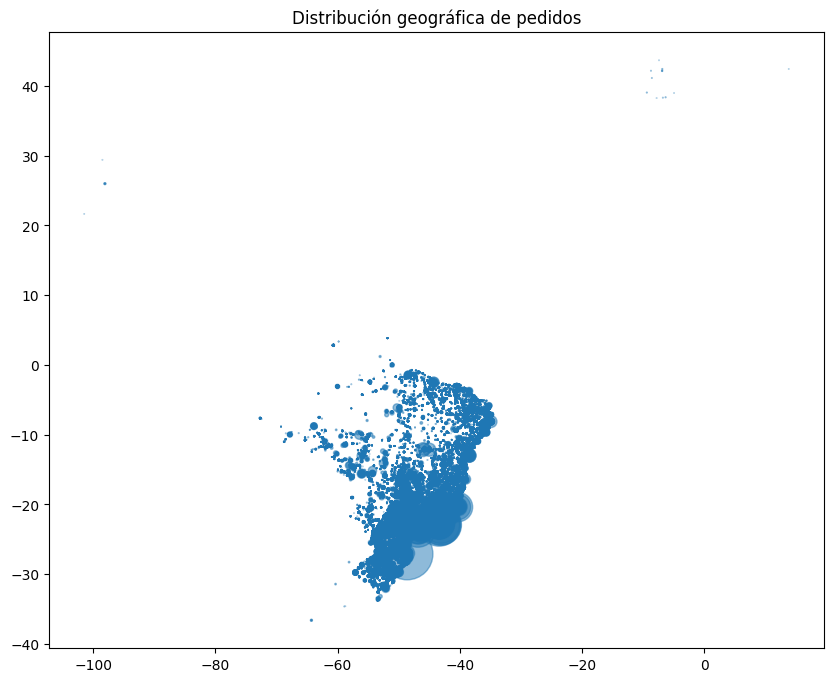

In [70]:
plt.figure(figsize=(10,8))

plt.scatter(
    geo_map["geolocation_lng"],
    geo_map["geolocation_lat"],
    s=geo_map["orders"]/10,
    alpha=0.5
)

plt.title("Distribución geográfica de pedidos")

plt.show()